In [1]:
import sys
import os
from tqdm import tqdm
# tambahin root project ke path
sys.path.append(os.path.abspath(".."))

In [2]:
from utils.dataloader import get_dataloader

In [3]:
BASE_DIR = os.path.abspath("..")

train_path = os.path.join(BASE_DIR, "data/WLBisindo/split/train")
val_path   = os.path.join(BASE_DIR, "data/WLBisindo/split/val")
test_path  = os.path.join(BASE_DIR, "data/WLBisindo/split/test")

print(train_path)

D:\Softwares\AnacondaProjects\GestureSequenceCNN\data/WLBisindo/split/train


In [4]:
import os

print("Train exists:", os.path.exists(train_path))
print("Val exists:", os.path.exists(val_path))
print("Test exists:", os.path.exists(test_path))

Train exists: True
Val exists: True
Test exists: True


In [5]:
from utils.dataloader import get_dataloader, get_transforms

train_transform, val_transform = get_transforms()

train_loader = get_dataloader(train_path, transform=train_transform)
val_loader   = get_dataloader(val_path, shuffle=False, transform=val_transform)
test_loader  = get_dataloader(test_path, shuffle=False, transform=val_transform)

In [7]:
for x, y in train_loader:
    print("Input shape :", x.shape)  # (B, 20, 3, 224, 224)
    print("Label shape :", y.shape) # (B,)
    print("Label sample:", y[:5])
    break

Input shape : torch.Size([8, 20, 3, 224, 224])
Label shape : torch.Size([8])
Label sample: tensor([ 9,  2,  7, 10, 15])
Input shape : torch.Size([8, 20, 3, 224, 224])
Label shape : torch.Size([8])
Label sample: tensor([23,  0, 18,  6, 25])


In [8]:
import os
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

# buat folder run unik
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

BASE_DIR = os.path.abspath("..")
log_dir = os.path.join(BASE_DIR, "outputs/logs/cnn_lstm", f"run_{timestamp}")

os.makedirs(log_dir, exist_ok=True)

writer = SummaryWriter(log_dir)

print("Log dir:", log_dir)

Log dir: D:\Softwares\AnacondaProjects\GestureSequenceCNN\outputs/logs/cnn_lstm\run_20260409_111427


In [9]:
log_file = os.path.join(log_dir, "log.txt")

def log_message(msg):
    print(msg)
    with open(log_file, "a") as f:
        f.write(msg + "\n")

In [10]:
# ambil jumlah kelas dari dataset
NUM_CLASSES = len(train_loader.dataset.label_map)

print("Num classes:", NUM_CLASSES)

Num classes: 32


In [11]:
from models.cnn_lstm import CNN_LSTM

model = CNN_LSTM(num_classes=NUM_CLASSES)

x, y = next(iter(train_loader))
out = model(x)

print(out.shape)

torch.Size([8, 32])


In [12]:
import torch
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = CNN_LSTM(num_classes=NUM_CLASSES).to(device)

# freeze semua
for param in model.encoder.cnn.parameters():
    param.requires_grad = False

# unfreeze layer4
for param in model.encoder.cnn[7].parameters():
    param.requires_grad = True

# ambil label dari dataset
labels = train_loader.dataset.labels  # pastikan ini ada

class_counts = Counter(labels)
total = sum(class_counts.values())

weights = [total / class_counts[i] for i in range(len(class_counts))]
weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=weights)

print("Class weights:", weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

Device: cuda
Class weights: tensor([26.2647, 63.7857, 27.9062, 25.5143, 38.8261, 29.7667, 26.2647, 31.8929,
        68.6923, 25.5143, 33.0741, 27.9062, 26.2647, 74.4167, 42.5238, 31.8929,
        37.2083, 30.7931, 27.9062, 31.8929, 35.7200, 40.5909, 28.8065, 63.7857,
        25.5143, 27.0606, 29.7667, 34.3462, 25.5143, 27.0606, 27.9062, 27.9062],
       device='cuda:0')


In [13]:
def compute_accuracy(preds, labels):
    preds = torch.argmax(preds, dim=1)
    correct = (preds == labels).sum().item()
    return correct / len(labels)

In [14]:
EPOCHS = 10
patience = 3
counter = 0
best_val_loss = float("inf")

import json

config = {
    "model": "CNN_LSTM",
    "epochs": EPOCHS,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "batch_size": train_loader.batch_size,
    "num_classes": NUM_CLASSES,
    "cnn_unfreeze": True
}

with open(os.path.join(log_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ===== TRAIN =====
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for x, y in train_bar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

        # update progress bar
        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total


    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in val_bar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

            # update progress bar
            val_bar.set_postfix({
                "loss": f"{loss.item():.4f}"
            })

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # ===== LOGGING =====
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)

    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)

    writer.add_scalar("Overfitting/gap", train_acc - val_acc, epoch)

    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar("LR", current_lr, epoch)

    for name, param in model.named_parameters():
        writer.add_histogram(f"Weights/{name}", param, epoch)

        if param.grad is not None:
            writer.add_histogram(f"Gradients/{name}", param.grad, epoch)

    log_message(f"Epoch {epoch+1}/{EPOCHS}")
    log_message(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    log_message(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")
    log_message(f"LR: {current_lr}")
    log_message("-" * 40)

    # ===== SCHEDULER =====
    scheduler.step(val_loss)


    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), os.path.join(log_dir, "best_model.pth"))
        log_message("Best model saved!")

    else:
        counter += 1
        log_message(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            log_message("Early stopping triggered!")
            break


# SAVE LAST MODEL
torch.save(model.state_dict(), os.path.join(log_dir, "last_model.pth"))


Epoch 1/10


Epoch 1/10
Train Loss: 3.4601 | Acc: 0.0392
Val   Loss: 3.4322 | Acc: 0.0824
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 2/10


Epoch 2/10
Train Loss: 3.3678 | Acc: 0.0829
Val   Loss: 3.1804 | Acc: 0.1703
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 3/10


Epoch 3/10
Train Loss: 3.0316 | Acc: 0.1534
Val   Loss: 2.7860 | Acc: 0.1868
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 4/10


Epoch 4/10
Train Loss: 2.6565 | Acc: 0.2508
Val   Loss: 2.3976 | Acc: 0.3352
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 5/10


...

Epoch 6/10
Train Loss: 2.1821 | Acc: 0.3113
Val   Loss: 2.0025 | Acc: 0.4835
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 7/10


Epoch 7/10
Train Loss: 1.9605 | Acc: 0.3751
Val   Loss: 1.8279 | Acc: 0.4780
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 8/10


Epoch 8/10
Train Loss: 1.8720 | Acc: 0.3942
Val   Loss: 1.7471 | Acc: 0.5495
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 9/10


Epoch 9/10
Train Loss: 1.7363 | Acc: 0.4412
Val   Loss: 1.5653 | Acc: 0.5879
LR: 0.0001
----------------------------------------
Best model saved!

Epoch 10/10


Epoch 10/10
Train Loss: 1.6195 | Acc: 0.4927
Val   Loss: 1.5062 | Acc: 0.6374
LR: 0.0001
----------------------------------------
Best model saved!


In [15]:
from utils.evaluate import evaluate

report_path = os.path.join(log_dir, "evaluation.json")

metrics = evaluate(
    model,
    test_loader,
    device,
    save_path=report_path,
    model_name="CNNResNetLSTM"
)

Evaluation Metrics:
accuracy: 0.6413
precision: 0.6126
recall: 0.6159
f1: 0.5817
hamming_loss: 0.3587
Experiment logged to: D:\Softwares\AnacondaProjects\GestureSequenceCNN\outputs/metrics\experiments.csv


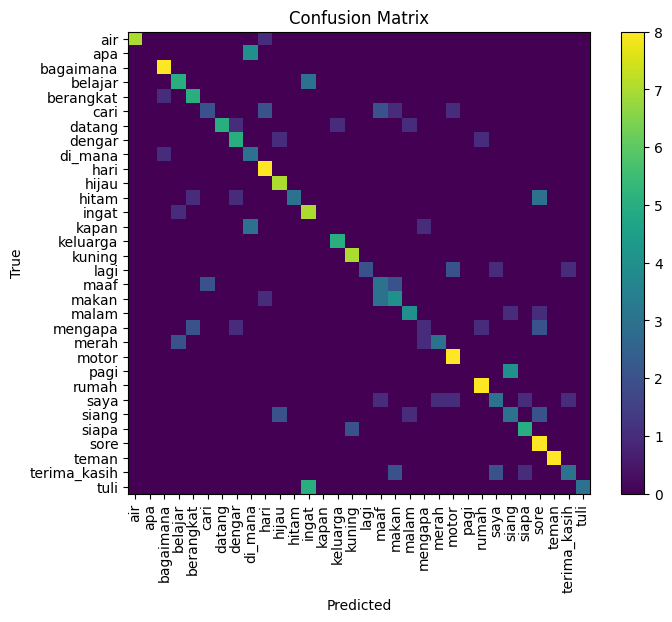

In [16]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

# plot
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")

labels = list(train_loader.dataset.label_map.keys())

plt.xticks(np.arange(len(labels)), labels, rotation=90)
plt.yticks(np.arange(len(labels)), labels)

plt.savefig(os.path.join(log_dir, "confusion_matrix.png"))
plt.show()